## ***PREDICTING LOAN AMOUNTS***


### ***Problem Statement:***
#### This project aims to develop a predictive model that estimates the loan amount a customer is likely to apply for based on demographic, financial, and credit-related attributes.Using exploratory data analysis, feature engineering, and regression techniques, the model will identify key factors influencing loan demand.The dataset will be preprocessed to handle missing values, outliers, and categorical encoding before training.Model performance will be evaluated using appropriate regression metrics to ensure accuracy and reliability.The final outcome will support data-driven decision-making for financial institutions in loan planning and risk assessment.

### ***Objective: Predict the amount of loan a customer will apply for based on their profile.***

## EDA(Exploratory Data Analysis)

## Data Description

## Dataset

[loan.csv](https://www.kaggle.com/datasets/tanishaj225/loancsv?resource=download)


Click in above link for dataset source.

In [154]:
#Libraries used 
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [155]:

df = pd.read_csv('loan.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [156]:
df = pd.read_csv('loan.csv')
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


The above outputs shows the first and last five rows of the csv file which we are using for modal training.

In [157]:
#Getting features  
import numpy as np
import pandas as pd

loan=pd.read_csv("loan.csv")
loan.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


### There are toal 13 columns in loan.csv files with 5 features i.e ApplicantIncome ,CoapplicantIncome,LoanAmount,Loan_Amount_Term  were found to be Quantitative data and rest were found to be Qualitative data.The Loan_ID is not catagorized as it has no use in loan prediction.Also there is no any interval data found.

## Nominal data including features: 
- ### Gender,Married,Education,Self_Employed,Property_Area and Loan_status

## Ordinal data including features
-  ### Dependents,Credit_history,Loan_Amount_Term

## Ratio data including features
- ### ApplicantIncome ,CoapplicantIncome,LoanAmount

In [158]:
loan.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


From .describe() method we were able to analyze that Loan_Amount_Term ,LoanAMount and Credit_History has some missing values.We handle the missing values in Data Wrangling process below. Also we can observe the mean ,std,min,Q1,median,Q3, and max value of quantitave data types.

## ***Data Wrangling***

### Handling Missing and Duplicate values

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


<Axes: >

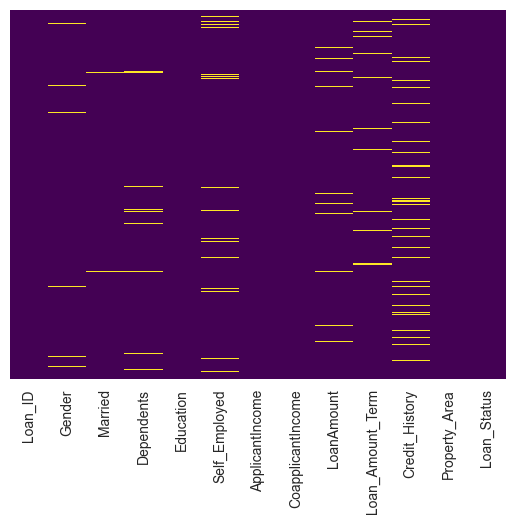

In [159]:
# checking of null values 


null=loan.isnull().sum() #null value check
print(null)

#visualization of null values 
sns.heatmap(loan.isnull(),yticklabels=False,cbar=False,cmap='viridis')

#### ***Hence total null values for each features is calculated using isnull().sum() method.The null value count for each features can be seen in the output above.Additionally Heatmap was used for visualization of null values in each features.***

In [160]:
#checking duplicate values


duplicate_value=loan.duplicated().sum() #duplicate value check
print(duplicate_value)


0


### There was no duplicate data found in the dataset.

In [161]:


loan=pd.read_csv("loan.csv")


#removing Loan_ID
loan.drop(['Loan_ID'],axis=1,inplace=True)
loan.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Dependents         599 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      582 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


#### We removed the Loan_Id feature as this is of use use for loan amount prediction.

In [162]:
#Checking unique value
loan.nunique()

Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

### The number of unique value in each features can be seen from above output.

In [163]:
#Checking unique value of credit_history
print(loan['Credit_History'].unique())

#checking the percentage of missing credit_history rows
per=loan['Credit_History'].isnull().mean() * 100
print(per)

#Replacing missing credit_history with mode value
mode_value = loan['Credit_History'].mode()[0]
print(mode_value)
loan['Credit_History']=loan['Credit_History'].fillna(mode_value)

#Again checking for null value
print(loan['Credit_History'].isnull().sum())


[ 1.  0. nan]
8.143322475570033
1.0
0


The Credit_History variable contains binary values (0 and 1) with some missing entries.The null values percentage is about 8.14332 which may cause significant data lost and it is a strong predictor for loan.
Since it is a categorical feature, missing values were imputed using the mode to preserve the original distribution.
After imputation, no null values remain, making the feature ready for model training.

In [164]:
# Drop rows where catagorical columns have missing values
loan.dropna(subset=['Gender', 'Married', 'Dependents', 'Self_Employed'], inplace=True)
# Check remaining rows and columns
print(f"Remaining data shape: {loan.shape}")
print(f"Remaining number of rows: {len(loan)}")

Remaining data shape: (554, 12)
Remaining number of rows: 554


We removed the rows with missing values in 'Gender', 'Married', 'Dependents', 'Self_Employed' as there is no significant data loss.

Skewness: 2.5362165808605535


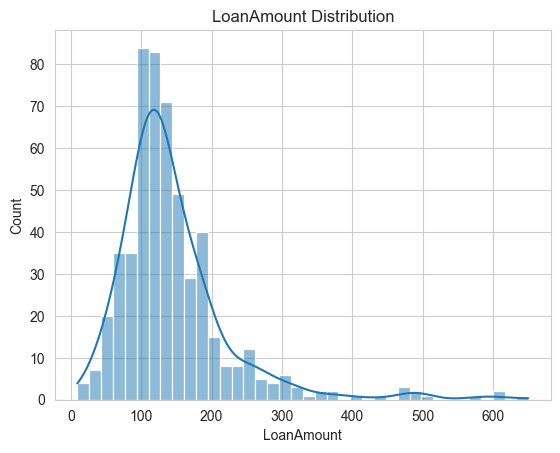

In [165]:

print("Skewness:", loan['LoanAmount'].skew())

sns.histplot(loan['LoanAmount'], kde=True)
plt.title("LoanAmount Distribution")
plt.show()


#Filling the missing Loan Amount with median
loan['LoanAmount'] = loan['LoanAmount'].fillna(loan['LoanAmount'].median())

We replace the missing LoanAmount by median value as LoanAmount is a continuous numerical variable, and in loan datasets it is  right-skewed.

In [166]:
#Filling the missing Loan_Amount_Term with mode value
loan['Loan_Amount_Term'] = loan['Loan_Amount_Term'].fillna(loan['Loan_Amount_Term'].mode()[0])

As Loan_Amount_Term is a catagorical value so mode imputation was used to fill missing values.

In [167]:
# Check remaining missing values
check=loan.isnull().sum()
print(check)


# Save the DataFrame to a new CSV file
loan.to_csv('loan_data_cleaned.csv', index=False)

#checking the values
loan.info()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 554 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             554 non-null    object 
 1   Married            554 non-null    object 
 2   Dependents         554 non-null    object 
 3   Education          554 non-null    object 
 4   Self_Employed      554 non-null    object 
 5   ApplicantIncome    554 non-null    int64  
 6   CoapplicantIncome  554 non-null    float64
 7   LoanAmount         554 non-null    float64
 8   Loan_Amount_Term   554 non-null    float64
 9   Credit_History     554 non-null    float64
 10  Property_Area      554 non-nul

After the data cleaning was done no missing values was remaining so we are ready to go for further analysis and training and cleaned data was saved to loan_data_cleaned.csv.

     Gender Married Dependents Education Self_Employed  ApplicantIncome  \
549  Female      No          0  Graduate            No             2900   
550    Male     Yes         3+  Graduate            No             4106   
551    Male     Yes          1  Graduate            No             8072   
552    Male     Yes          2  Graduate            No             7583   
553  Female      No          0  Graduate           Yes             4583   

     CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
549                0.0        71.0             360.0             1.0   
550                0.0        40.0             180.0             1.0   
551              240.0       253.0             360.0             1.0   
552                0.0       187.0             360.0             1.0   
553                0.0       133.0             360.0             0.0   

    Property_Area Loan_Status  Interest_Rate  
549         Rural           Y              8  
550         Rural     

<Axes: >

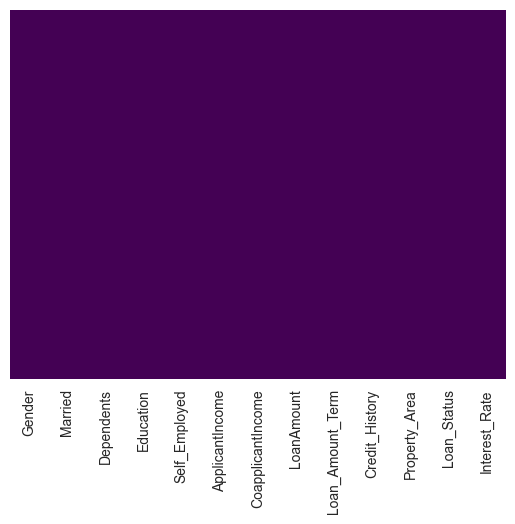

In [168]:
import numpy as np
import pandas as pd


loan=pd.read_csv("loan_data_cleaned.csv")
income_total = loan['ApplicantIncome'] + loan['CoapplicantIncome']
loan_amount = loan['LoanAmount']
loan_term = loan['Loan_Amount_Term']

# Simple formula to calculate synthetic interest rate
# Base rate of 6% + adjustments for risk
loan['Interest_Rate'] = (
    6  # base rate
    + (loan_amount / loan_amount.max()) * 4   # up to +4% for large loans
    + (loan_term / loan_term.max()) * 2      # up to +2% for long terms
    - (income_total / income_total.max()) * 2  # reduce up to -2% for high income
)

# Round to 2 decimal places
loan['Interest_Rate'] = loan['Interest_Rate'].round(2)
#Round to integer value
loan['Interest_Rate'] = loan['Interest_Rate'].round(0).astype(int)

# Ensure rates are within a realistic range (6% to 12%)
loan['Interest_Rate'] = loan['Interest_Rate'].clip(6, 12)


# Save the DataFrame to a new CSV file
loan.to_csv('loan_data_cleaned.csv', index=False)


#checking the values
# loan.head()
print(loan.tail())

#visualizaton for any missing values after data cleaning
sns.heatmap(loan.isnull(),yticklabels=False,cbar=False,cmap='viridis')


#### ***The script generates a synthetic interest rate for each loan in the loan_data.csv dataset. Starting from a base rate of 6%, the rate increases for larger loans (up to +4%) and longer loan terms (up to +2%) while decreasing for higher total applicant income (up to -2%). The rates are rounded to integers and limited to a realistic range of 6%–12%. The updated dataset, including the new Interest_Rate column, is saved back to the CSV for further analysis.The heat map shows no null value so our dataset was free of null value and ready for further training***


## **Encoding**

In [169]:
#Encoding
obj = (loan.dtypes == 'object')
print("Categorical variables:",len(list(obj[obj].index)))

Categorical variables: 7


In [170]:
# Print all categorical variables (object dtype) in the DataFrame
categorical_vars = loan.select_dtypes(include=['object']).columns.tolist()
print('Categorical variables:', categorical_vars)

Categorical variables: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


In [171]:
from sklearn import preprocessing
label_encoder = preprocessing.LabelEncoder()

cols = ['Gender','Married','Education','Self_Employed','Property_Area','Loan_Status','Dependents']
for col in cols:
  loan[col] = label_encoder.fit_transform(loan[col])


  #Encoding
obj = (loan.dtypes == 'object')
print("Categorical variables:",len(list(obj[obj].index)))

Categorical variables: 0


In [172]:
# Print all categorical variables (object dtype) in the DataFrame
categorical_vars = loan.select_dtypes(include=['object']).columns.tolist()
print('Categorical variables:', categorical_vars)

Categorical variables: []


## Outlier Handling

### Z score Test for Numeric features


Number of outliers in ApplicantIncome: 5
Number of outliers in CoapplicantIncome: 5
Number of outliers in LoanAmount: 12
Percentage of outliers in ApplicantIncome: 0.90%
Percentage of outliers in CoapplicantIncome: 0.90%
Percentage of outliers in LoanAmount: 2.17%


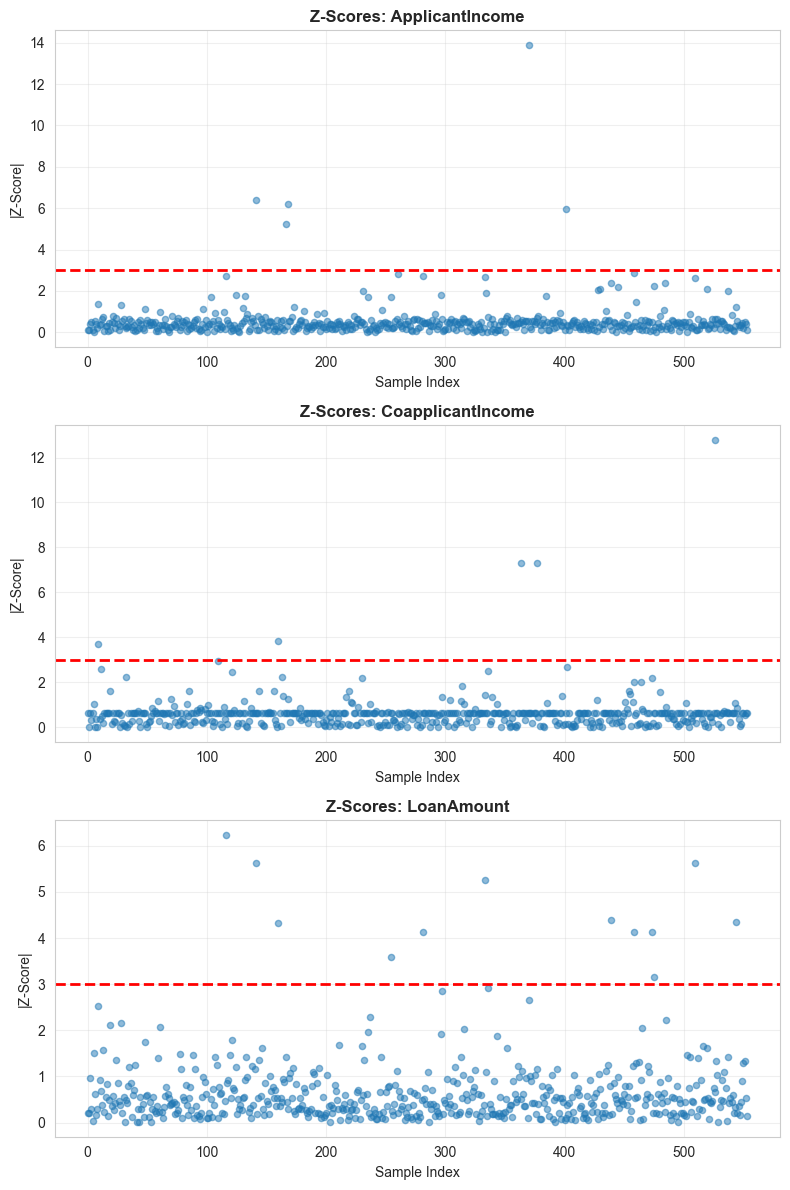

In [173]:

# Numeric features
numeric_features = [
    'ApplicantIncome', 
    'CoapplicantIncome', 
    'LoanAmount'
]

# Compute absolute z-scores
z_scores_df = pd.DataFrame(np.abs(stats.zscore(loan[numeric_features])), columns=numeric_features)


# Outlier threshold
threshold = 3

#printing outliers number
for feature in numeric_features:
    outliers = z_scores_df[z_scores_df[feature] > threshold]
    print(f"Number of outliers in {feature}: {len(outliers)}")

for feature in numeric_features:
    outliers = z_scores_df[z_scores_df[feature] > threshold]
    percentage = (len(outliers) / len(loan)) * 100  
    print(f"Percentage of outliers in {feature}: {percentage:.2f}%")

# Plot z-scores
fig, axes = plt.subplots(3, 1, figsize=(8, 12))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    axes[i].scatter(range(len(z_scores_df)), z_scores_df[feature], alpha=0.5, s=20)
    axes[i].axhline(y=threshold, color='r', linestyle='--', linewidth=2)
    axes[i].set_title(f'Z-Scores: {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('|Z-Score|')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('zscore_outlier_analysis.png', dpi=300, bbox_inches='tight')
plt.show()





## Scaling Numeric Features

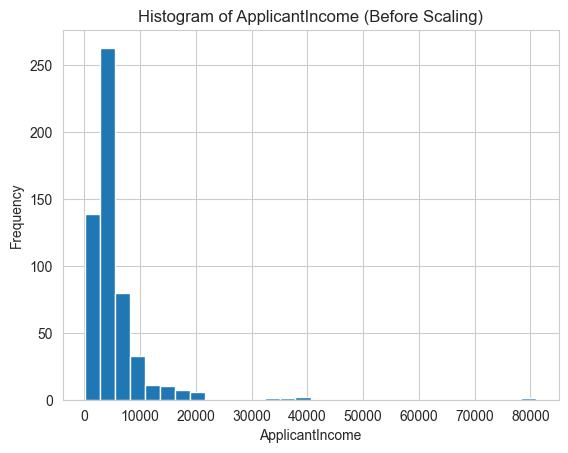

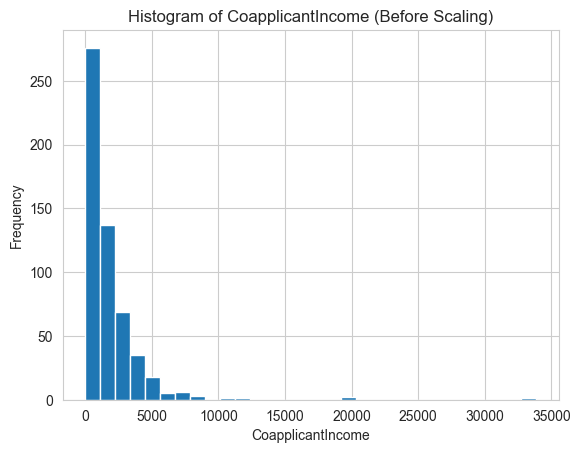

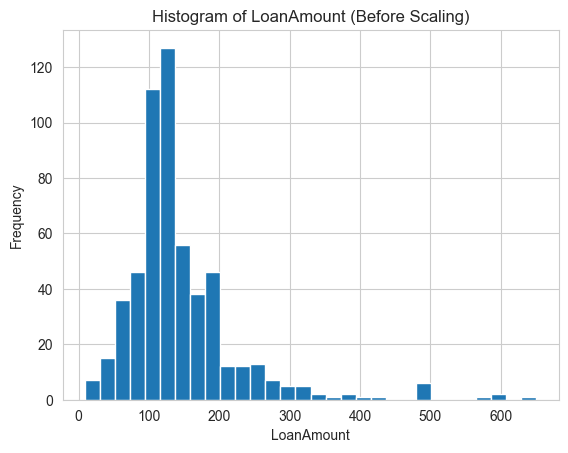

In [174]:


# List of numeric features
numeric_features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

for feature in numeric_features:
    plt.figure()
    plt.hist(loan[feature], bins=30)
    plt.title(f'Histogram of {feature} (Before Scaling)')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()



In [175]:


# List of numeric features to scale
numeric_features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on the numeric features and transform them
loan[numeric_features] = scaler.fit_transform(loan[numeric_features])

# Display the first 5 rows to check the scaled values
loan.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Interest_Rate
0,1,0,0,0,0,0.106773,-0.628647,-0.213435,360.0,1.0,2,1,8
1,1,1,1,0,0,-0.125510,-0.030757,-0.201100,360.0,1.0,0,0,8
2,1,1,0,0,1,-0.415956,-0.628647,-0.965868,360.0,1.0,2,1,8
3,1,1,0,1,0,-0.492467,0.306250,-0.299780,360.0,1.0,2,1,8
4,1,0,0,0,0,0.134479,-0.628647,-0.040745,360.0,1.0,2,1,8


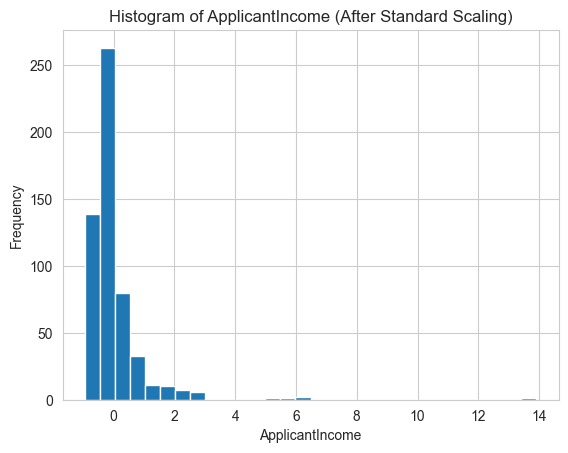

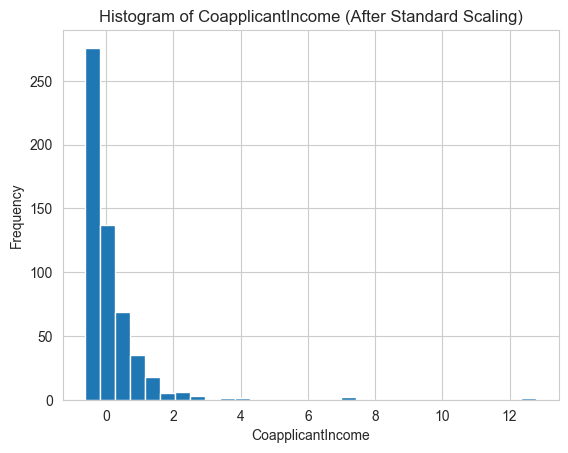

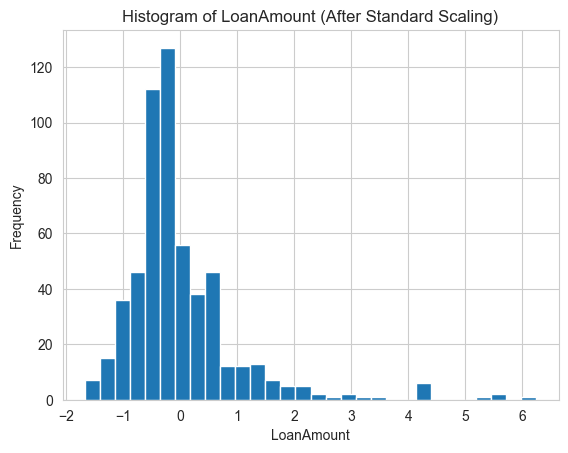

In [176]:
import matplotlib.pyplot as plt

# List of numeric features
numeric_features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

for feature in numeric_features:
    plt.figure()
    plt.hist(loan[feature], bins=30)
    plt.title(f'Histogram of {feature} (After Standard Scaling)')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

As there is no significant difference on original dataset on scaling so its not necessary for scaling.So we are going to loan original loan_data_cleaned.csv with no scaling of numeric feature and use it for further analysis.

## Feature Distribution

### Analysis for numeric features:
####  Applicant_Income,Co_Applicant Income and Loan_Amount

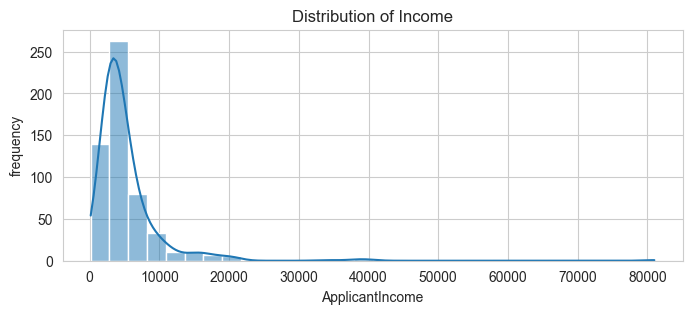

Skewness value of ApplicantIncome:  6.881481307608678


In [177]:
#Task 1
# Load dataset
loan = pd.read_csv("loan_data_cleaned.csv")

#For ApplicantIncome
plt.figure(figsize=(8,3))
sns.histplot(data=loan["ApplicantIncome"],bins=30,kde=True)
plt.title('Distribution of Income')
plt.xlabel('ApplicantIncome')
plt.ylabel('frequency')
plt.show()
print("Skewness value of ApplicantIncome: ", loan["ApplicantIncome"].skew())

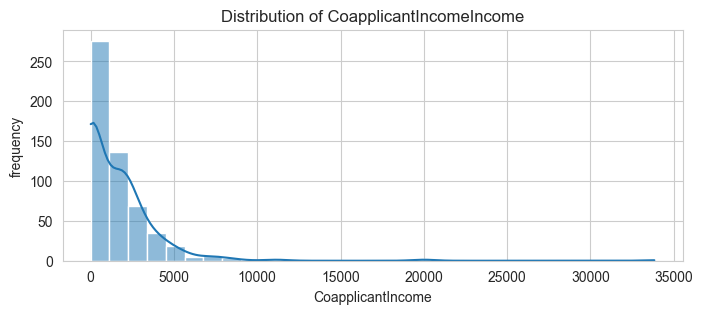

Skewness value of CoapplicantIncome:  5.736590070617913


In [178]:
#For Co_Applicant_income
plt.figure(figsize=(8,3))
sns.histplot(data=loan["CoapplicantIncome"],bins=30,kde=True)
plt.title('Distribution of CoapplicantIncomeIncome')
plt.xlabel('CoapplicantIncome')
plt.ylabel('frequency')
plt.show()
print("Skewness value of CoapplicantIncome: ", loan["CoapplicantIncome"].skew())



Based on the provided visualizations and statistical metrics, the dataset exhibits a high degree of positive skewness across all income categories, with ApplicantIncome showing the most extreme value (6.88). This indicates that while the majority of applicants fall within a lower income bracket (typically under 10,000), there are significant high-income outliers that stretch the distribution's tail to the right.Also the CoapplicantIncome also shows the positive skewness of 5.73.Majority of values clustered near 0–3000.Long tail extending up to ~35,000.Clear presence of extreme outliers

## Log Transform for skewed Numeric Features

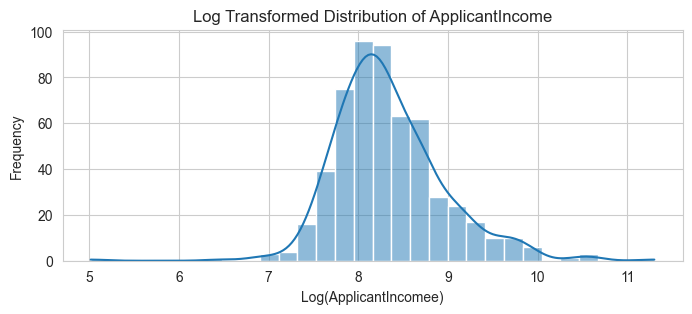

Log Transformed Skewness: 0.6061088370540718


In [179]:
#Create log transformed feature
loan['ApplicantIncome_log'] = np.log1p(loan['ApplicantIncome'])

# Plot Log Transformed Distribution
plt.figure(figsize=(8,3))
sns.histplot(data=loan["ApplicantIncome_log"], bins=30, kde=True)
plt.title('Log Transformed Distribution of ApplicantIncome')
plt.xlabel('Log(ApplicantIncomee)')
plt.ylabel('Frequency')
plt.show()

print("Log Transformed Skewness:", loan["ApplicantIncome_log"].skew())

After the Log transorm the Applicant_Income was distributed properly as normal distribution and the skewness also becomes 0.60 which is moderately skewed and suitable for modal training.

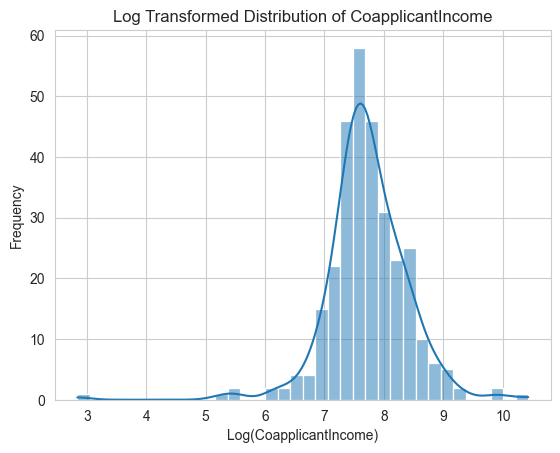

Log Transformed Skewness: -0.1759706652576029


In [180]:
# Log transformation (safe for zero values)
# loan = loan[loan["CoapplicantIncome"] > 0]

loan['CoapplicantIncome_log'] = np.log1p(loan['CoapplicantIncome'])



# Plot Log Transformed Distribution
# Create a temporary view without zeros for plotting
sns.histplot(loan[loan['CoapplicantIncome'] > 0]['CoapplicantIncome_log'], kde=True)
plt.title("Distribution of Non-Zero Coapplicant Income")
plt.title('Log Transformed Distribution of CoapplicantIncome')
plt.xlabel('Log(CoapplicantIncome)')
plt.ylabel('Frequency')
plt.show()

print("Log Transformed Skewness:", loan["CoapplicantIncome_log"].skew())

As -1 skewness is also moderately skewed so we keep the log transformed co_applicant income.

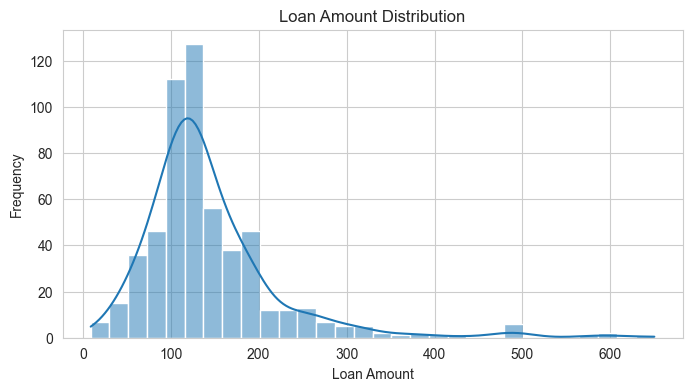

Skewness: 2.5967809078515027


In [181]:
# Loan Amount
plt.figure(figsize=(8,4))
sns.histplot(data=loan, x='LoanAmount', bins=30, kde=True)
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()
print("Skewness:", loan["LoanAmount"].skew())

As the loan amount is also right skewed we use log transformation.


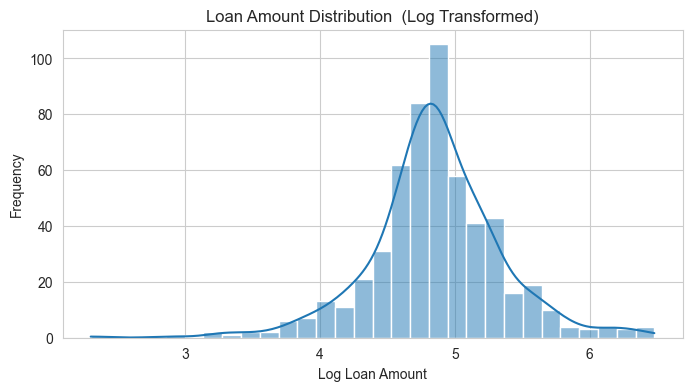

Log Transformed Skewness: -0.2561424033591042


In [182]:
loan['LoanAmount_log'] = np.log1p(loan['LoanAmount'])

#plot of log transformed loanamount
plt.figure(figsize=(8,4))
sns.histplot(data=loan, x='LoanAmount_log', bins=30, kde=True)
plt.title('Loan Amount Distribution  (Log Transformed)')
plt.xlabel('Log Loan Amount')
plt.ylabel('Frequency')
plt.show()
print("Log Transformed Skewness:", loan["LoanAmount_log"].skew())



 skew (-0.256) is suitable, so we don’t need further transformation.

In [183]:
# Check remaining rows and columns
print(f"Remaining data shape: {loan.shape}")
print(f"Remaining number of rows: {len(loan)}")

Remaining data shape: (554, 16)
Remaining number of rows: 554


The total number of rows remains unchanged after handling skewness.But 3 columns increased which is of log transformed ApplicantIncome,CoApplicant_Income and LoanAmount.

## Visualization for catagorical features

Categorical variables: 7


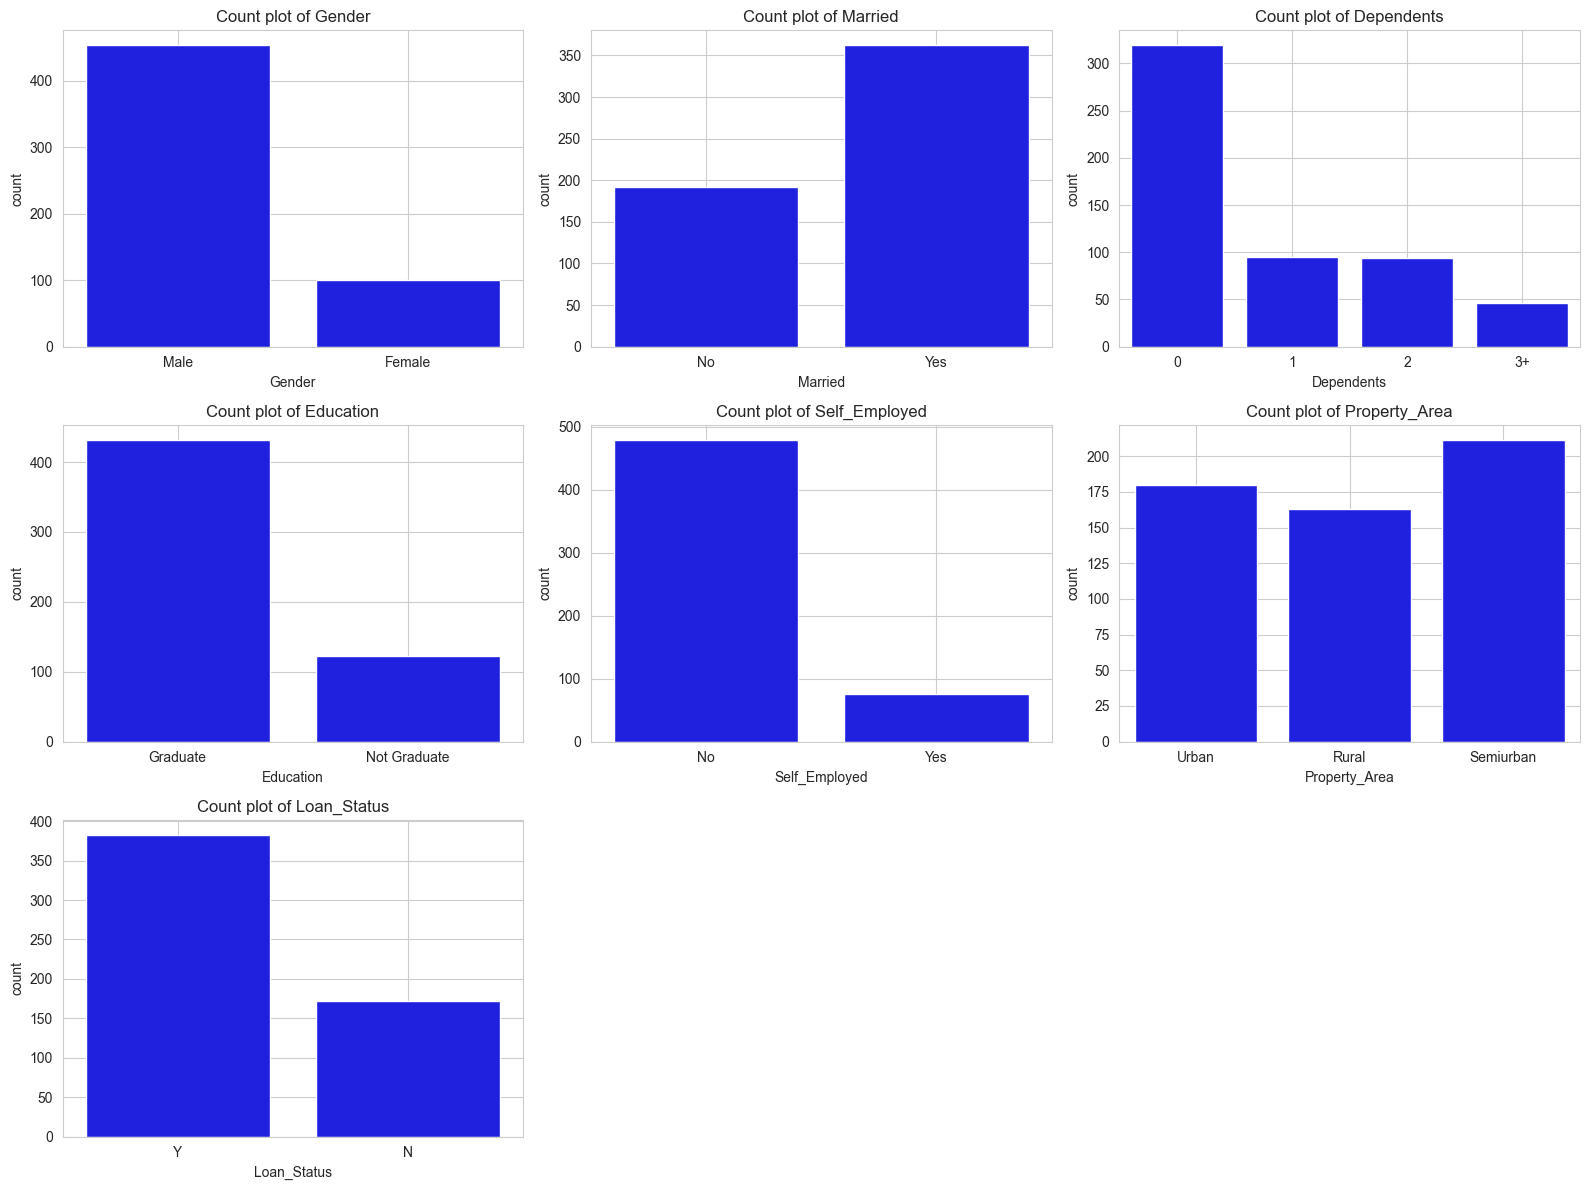

Counts for Gender:
Gender
Male      453
Female    101
Name: count, dtype: int64
Counts for Married:
Married
Yes    362
No     192
Name: count, dtype: int64
Counts for Dependents:
Dependents
0     319
1      95
2      94
3+     46
Name: count, dtype: int64
Counts for Education:
Education
Graduate        431
Not Graduate    123
Name: count, dtype: int64
Counts for Self_Employed:
Self_Employed
No     478
Yes     76
Name: count, dtype: int64
Counts for Property_Area:
Property_Area
Semiurban    211
Urban        180
Rural        163
Name: count, dtype: int64
Counts for Loan_Status:
Loan_Status
Y    382
N    172
Name: count, dtype: int64
Remaining data shape: (554, 16)
Remaining number of rows: 554


In [184]:
obj = (loan.dtypes == 'object')
print("Categorical variables:",len(list(obj[obj].index)))

categorical_features = ['Gender', 'Married', 'Dependents', 'Education', 
                        'Self_Employed', 'Property_Area', 'Loan_Status']

# Set plot style
sns.set_style("whitegrid")
plot_color = 'blue'

plt.figure(figsize=(16, 12))
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(3, 3, i)  # Grid layout
    sns.countplot(data=loan, x=feature, color=plot_color)
    plt.title(f'Count plot of {feature}')
    plt.tight_layout()
    plt.grid(True)
plt.show()

# Print counts for each categorical feature
for feature in categorical_features:
    print(f"Counts for {feature}:")
    print(loan[feature].value_counts(dropna=False))

# Check remaining rows and columns
print(f"Remaining data shape: {loan.shape}")
print(f"Remaining number of rows: {len(loan)}")

The dataset has 453 male applicants and 101 female applicants.
Most people are married (362) compared to unmarried (192).
Around 319 applicants have 0 dependents, while very few have 3 or more (under 50).
About 431 are graduates and 123 are not graduates.
478 are not self-employed, only about 76 are self-employed.
Property area shows the highest count in Semiurban (over 200), followed by Urban (around 180), then Rural (around 160).
Finally, Loan_Status shows about 382 approvals (Y) and around 172 rejections (N).
            
            
The  3 log transformed numerical features causes the feature size to be 16.


## Assigned EDA 

In [185]:
#1. Target Variable Analysis (LoanAmount)
print(loan.columns)
loan["LoanAmount"].describe()

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'Interest_Rate', 'ApplicantIncome_log', 'CoapplicantIncome_log',
       'LoanAmount_log'],
      dtype='object')


count    554.000000
mean     144.303249
std       81.143623
min        9.000000
25%      100.000000
50%      127.000000
75%      166.750000
max      650.000000
Name: LoanAmount, dtype: float64

#Task 1
In above program we were able to analyze the LoanAmount from the given dataset and find the mean,median,max,min and std value using describe() method where mean,median,max,min and std of LoanAmount was found to be 144.30249,127,650,9,81.143 respectively

        count        mean        std   min    25%    50%    75%    max
Gender                                                                
Female  101.0  125.009901  79.119719   9.0   84.0  113.0  137.0  600.0
Male    453.0  148.604857  81.048716  17.0  104.0  128.0  175.0  650.0

Average loan

Gender
Female    125.009901
Male      148.604857
Name: LoanAmount, dtype: float64


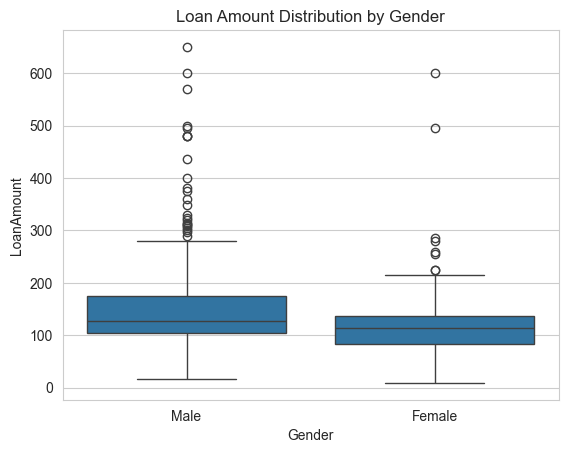

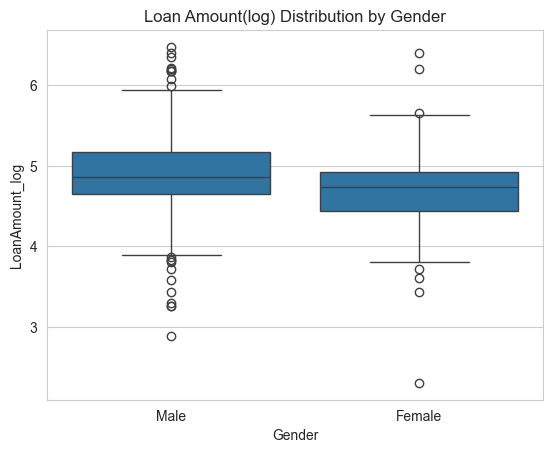

In [186]:
# 2. Demographic Analysis
dist_by_gender=loan.groupby('Gender')['LoanAmount'].describe()
print(dist_by_gender)
print('\nAverage loan\n')
dist_by_gender=loan.groupby("Gender")["LoanAmount"].mean()
print(dist_by_gender)

sns.boxplot(x='Gender', y='LoanAmount', data=loan)
plt.title("Loan Amount Distribution by Gender")
plt.show()

sns.boxplot(x='Gender', y='LoanAmount_log', data=loan)
plt.title("Loan Amount(log) Distribution by Gender")
plt.show()



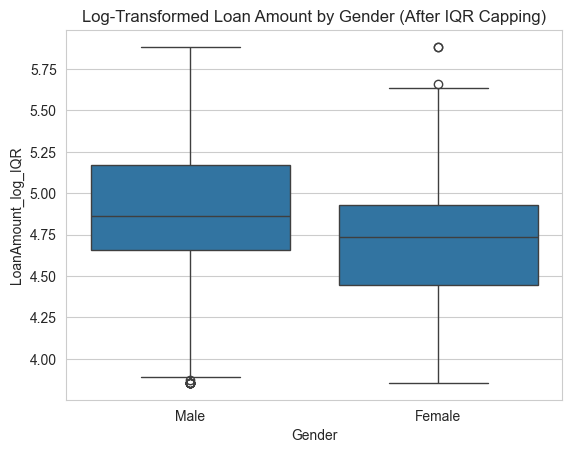

In [187]:
Q1 = loan['LoanAmount_log'].quantile(0.25)
Q3 = loan['LoanAmount_log'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
loan['LoanAmount_log_IQR'] = loan['LoanAmount_log'].clip(lower_bound, upper_bound)


sns.boxplot(x='Gender', y='LoanAmount_log_IQR', data=loan)
plt.title("Log-Transformed Loan Amount by Gender (After IQR Capping)")
plt.show()

The demographic analysis indicates that male applicants receive slightly higher average loan amounts than female applicants.Male applicants have average loan amount of 148.6k while female applicant have about 125k.The chart shows that male applicants generally request higher loan amounts than females, with males having a median around 140-150 compared to females at around 110-120. Both groups have a lot of high-value outliers stretching up to 600+, but males have significantly more, indicating some borrowers request unusually large loans. The distributions are heavily right-skewed, meaning most people request moderate amounts but a few request very large loans, which is why log transformation was needed. Overall, females tend to borrow more consistently in a smaller range, while males show greater variation in their loan requests.

Married
No     192
Yes    362
Name: LoanAmount, dtype: int64


average loan amount by martial status

Married
No     126.598958
Yes    153.693370
Name: LoanAmount, dtype: float64


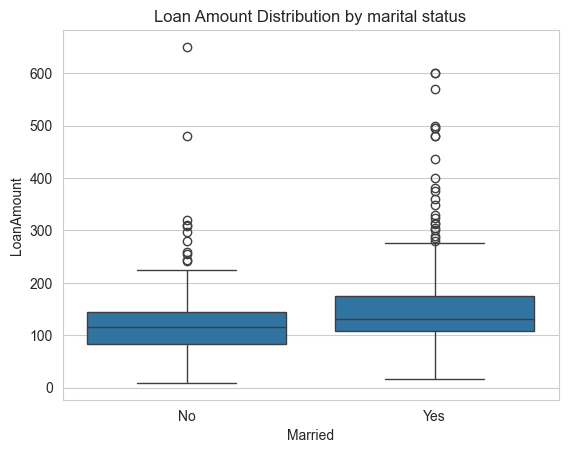

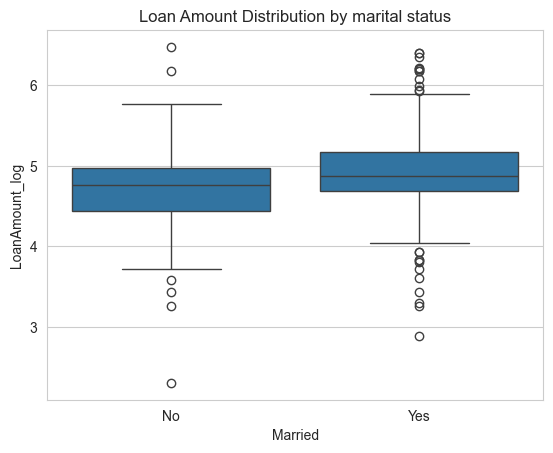

In [188]:
dist_by_Married_status=loan.groupby("Married")["LoanAmount"].size()
print(dist_by_Married_status)
print('\n')
print("average loan amount by martial status\n")
dist_by_Married_status=loan.groupby("Married")["LoanAmount"].mean()
print(dist_by_Married_status)

sns.boxplot(x='Married', y='LoanAmount', data=loan)
plt.title("Loan Amount Distribution by marital status")
plt.show()

sns.boxplot(x='Married', y='LoanAmount_log', data=loan)
plt.title("Loan Amount Distribution by marital status")
plt.show()

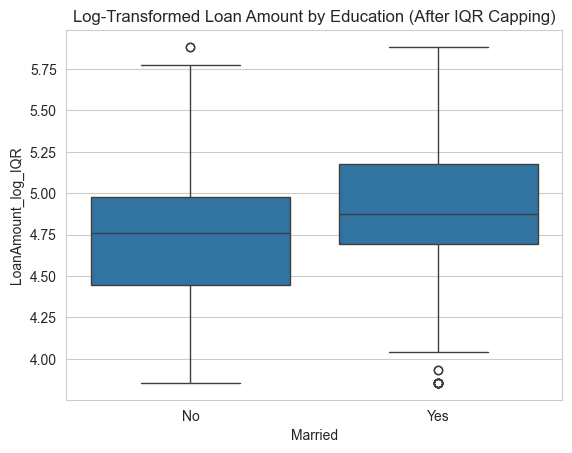

In [189]:
Q1 = loan['LoanAmount_log'].quantile(0.25)
Q3 = loan['LoanAmount_log'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
loan['LoanAmount_log_IQR'] = loan['LoanAmount_log'].clip(lower_bound, upper_bound)


sns.boxplot(x='Married', y='LoanAmount_log_IQR', data=loan)
plt.title("Log-Transformed Loan Amount by Education (After IQR Capping)")
plt.show()

Married applicants also show marginally higher loan amounts compared to unmarried applicants, though the difference is minimal.The box plot illustrates the distribution of loan amounts based on marital status, showing that married individuals generally take out larger loans than those who are not married. While both groups have a similar median loan amount—centered roughly between 100 and 150—the interquartile range for the married group is noticeably higher and wider, indicating greater variability in their borrowing. A significant number of high-value outliers appear in both categories, though the married group features a denser cluster of these extreme values, reaching up to 600. Conversely, the "No" (unmarried) category displays a more compact distribution with a lower maximum whisker, suggesting more conservative loan sizes. Overall, the data implies that while typical loans are comparable across status, the potential for substantial loan amounts is more pronounced among married applicants.

Dependents
0     319
1      95
2      94
3+     46
Name: LoanAmount, dtype: int64

Average loan

Dependents
0     134.181818
1     158.094737
2     152.500000
3+    169.260870
Name: LoanAmount, dtype: float64


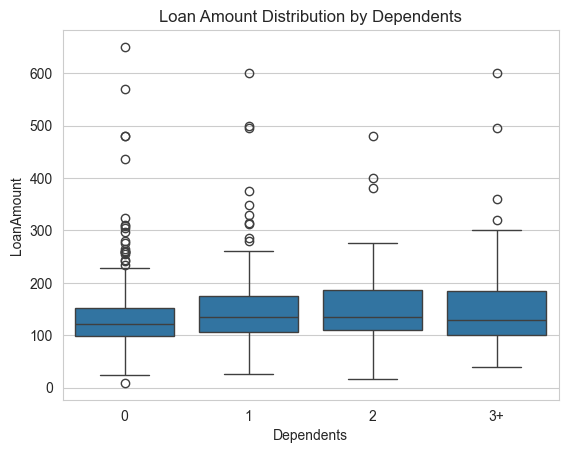

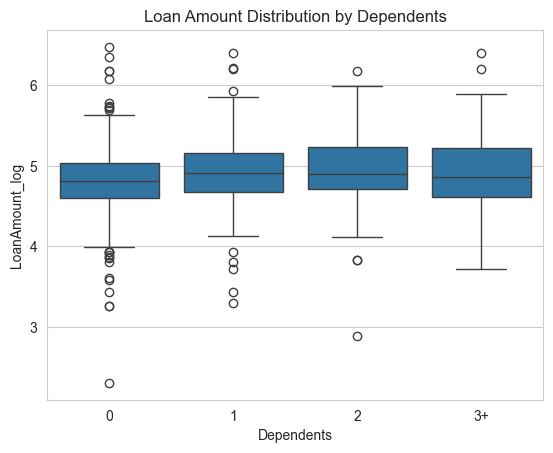

In [190]:
dist_by_dependents=loan.groupby("Dependents")["LoanAmount"].size()
print(dist_by_dependents)
print('\nAverage loan\n')
dist_by_dependents=loan.groupby("Dependents")["LoanAmount"].mean()
print(dist_by_dependents)

sns.boxplot(x='Dependents', y='LoanAmount', data=loan)
plt.title("Loan Amount Distribution by Dependents")
plt.show()


sns.boxplot(x='Dependents', y='LoanAmount_log', data=loan)
plt.title("Loan Amount Distribution by Dependents")
plt.show()


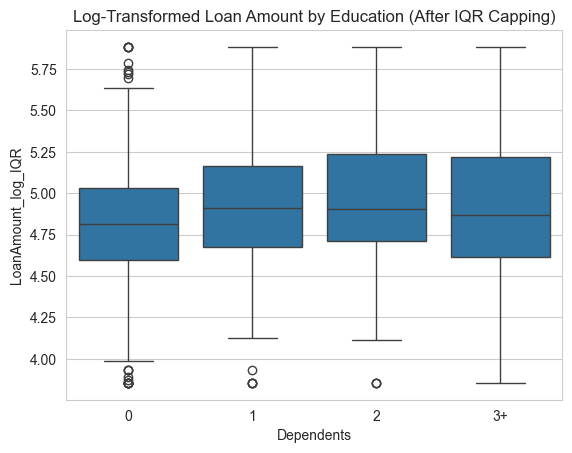

In [191]:
Q1 = loan['LoanAmount_log'].quantile(0.25)
Q3 = loan['LoanAmount_log'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
loan['LoanAmount_log_IQR'] = loan['LoanAmount_log'].clip(lower_bound, upper_bound)


sns.boxplot(x='Dependents', y='LoanAmount_log_IQR', data=loan)
plt.title("Log-Transformed Loan Amount by Education (After IQR Capping)")
plt.show()

The plot shows that personnel with 0 dependents have higher loan amount.The median loan amount remains very consistent regardless of the number of dependents, with most typical values falling between 120 and 150. While all groups show  several high-value outliers, the "0" dependents category has the most extreme requests reaching over 600. Ultimately, having more dependents does not drastically change the typical loan size applied for, though the presence of extreme, high-value loans is most frequent among those with no dependents.

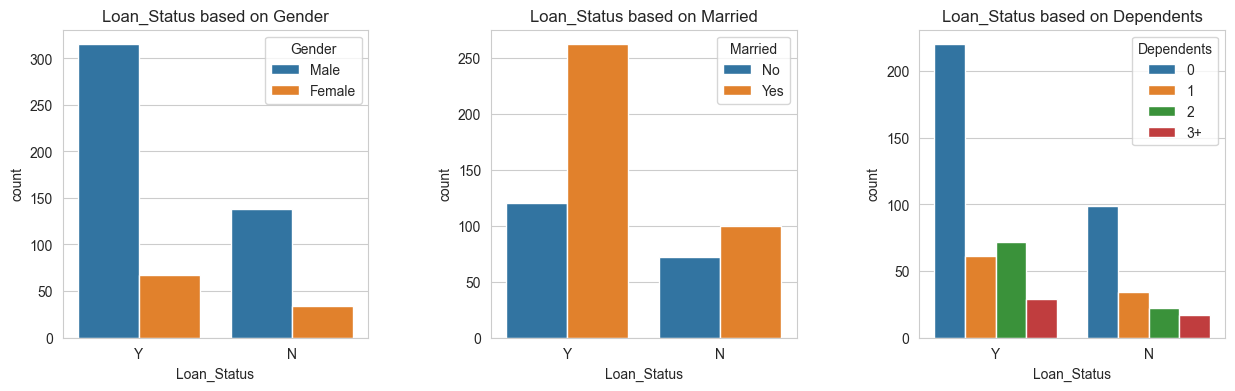

In [192]:
#Countplots for Loan Status by Gender, Married, and Dependents
fig,axes = plt.subplots(1, 3, figsize=(15,4))

sns.countplot(ax=axes[0],x='Loan_Status',hue='Gender',data=loan)
axes[0].set_title("Loan_Status based on Gender")
sns.countplot(ax=axes[1],x='Loan_Status',hue='Married',data=loan)
axes[1].set_title("Loan_Status based on Married")
sns.countplot(ax=axes[2],x='Loan_Status',hue='Dependents',data=loan)
axes[2].set_title("Loan_Status based on Dependents")
plt.subplots_adjust(wspace=0.4)
plt.show()

The charts show that more men, married people, and those without children get their loans approved. While men have the highest number of both approved and denied loans, married applicants have a much larger gap between success and failure than single people. The data also shows that as the number of children or dependents goes up, the number of people applying for loans goes down. Overall, the most common type of person getting a loan in this group is a married man with no kids.

              count        mean        std   min    25%    50%    75%    max
Education                                                                   
Graduate      431.0  151.677494  88.133200   9.0  103.0  130.0  175.5  650.0
Not Graduate  123.0  118.463415  40.034676  25.0   96.5  116.0  132.5  279.0


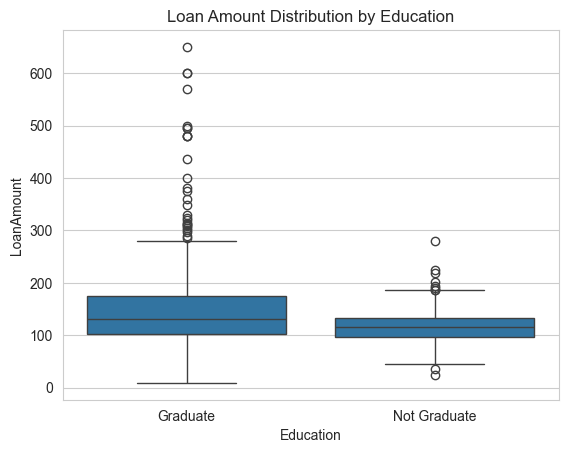

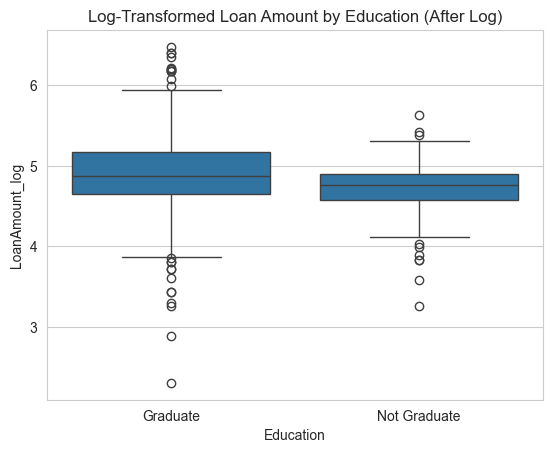

In [193]:
#Task 3
by_education=loan.groupby("Education")["LoanAmount"].describe()
print(by_education)

sns.boxplot(x='Education', y='LoanAmount', data=loan)
plt.title("Loan Amount Distribution by Education")
plt.show()

sns.boxplot(x='Education',y='LoanAmount_log',data=loan)
plt.title("Log-Transformed Loan Amount by Education (After Log)")
plt.show()

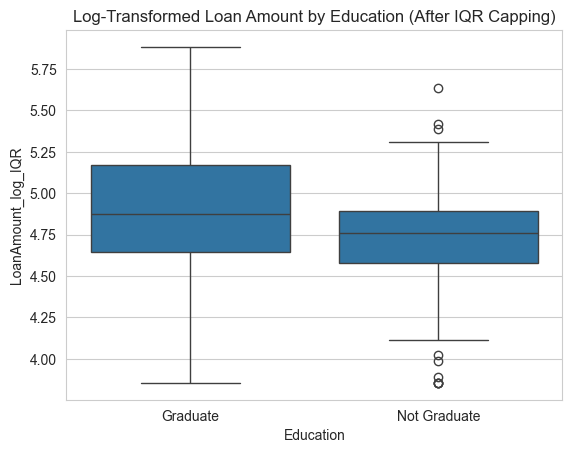

In [194]:
Q1 = loan['LoanAmount_log'].quantile(0.25)
Q3 = loan['LoanAmount_log'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
loan['LoanAmount_log_IQR'] = loan['LoanAmount_log'].clip(lower_bound, upper_bound)


sns.boxplot(x='Education', y='LoanAmount_log_IQR', data=loan)
plt.title("Log-Transformed Loan Amount by Education (After IQR Capping)")
plt.show()

#Task 3

The analysis of LoanAmount by education shows that graduates receive slightly higher average loans (151.677494) than non-graduates (118.463415), with median values showing a similar pattern.The plot shows that regardless of education level, most people apply for similar loan amounts, typically centered between 100 and 150. While the "average" applicant asks for a modest amount, the Graduate group has a much wider range of requests, including several very high-value loans that pull the overall average upward. Essentially, education doesn't change the "typical" loan size, but it does appear to increase the frequency of high-value loan applications.

               count        mean         std   min    25%    50%    75%    max
Self_Employed                                                                 
No             478.0  140.135983   74.961879   9.0  100.0  127.0  160.0  600.0
Yes             76.0  170.513158  109.556864  25.0  106.0  139.5  188.5  650.0


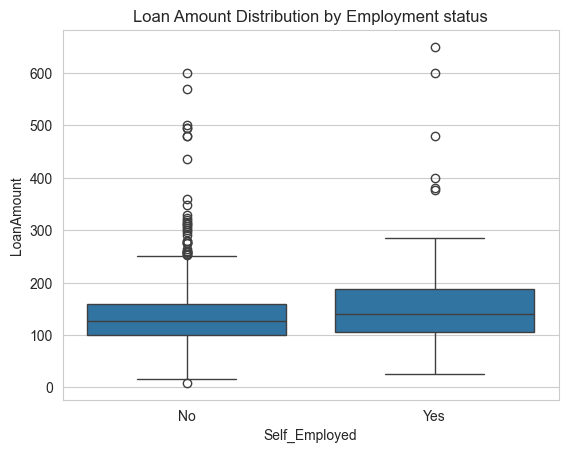

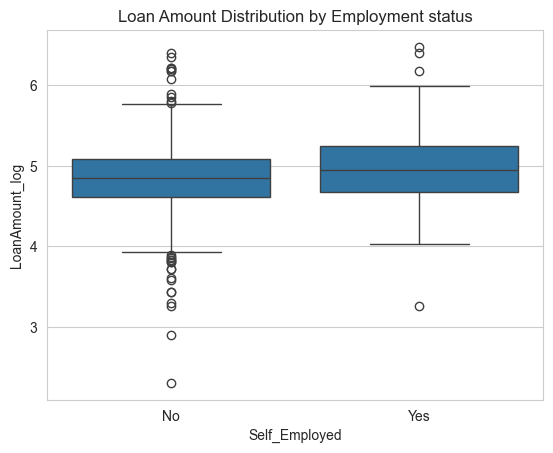

In [195]:
#Task 3
by_Self_Employed=loan.groupby("Self_Employed")["LoanAmount"].describe()
print(by_Self_Employed)

sns.boxplot(x='Self_Employed', y='LoanAmount', data=loan)
plt.title("Loan Amount Distribution by Employment status")
plt.show()


sns.boxplot(x='Self_Employed', y='LoanAmount_log', data=loan)
plt.title("Loan Amount Distribution by Employment status")
plt.show()

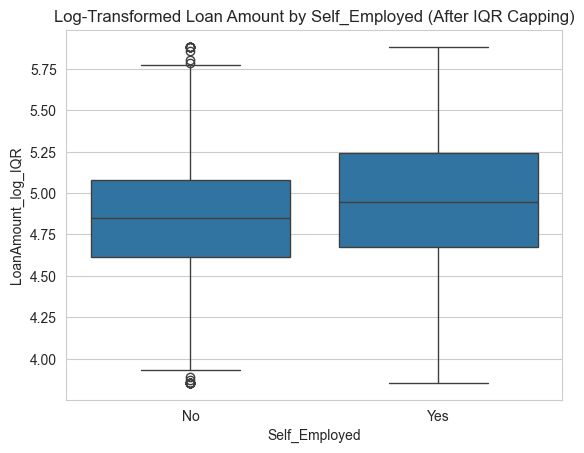

In [196]:
Q1 = loan['LoanAmount_log'].quantile(0.25)
Q3 = loan['LoanAmount_log'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
loan['LoanAmount_log_IQR'] = loan['LoanAmount_log'].clip(lower_bound, upper_bound)


sns.boxplot(x='Self_Employed', y='LoanAmount_log_IQR', data=loan)
plt.title("Log-Transformed Loan Amount by Self_Employed (After IQR Capping)")
plt.show()

For employment type, salaried applicants (Self_Employed = No) demands slightly lesser average loans (140.135983) than self-employed applicants (170.513158).

[Text(0.5, 1.0, 'Loan_Status based on Self_Employed')]

<Figure size 1000x400 with 0 Axes>

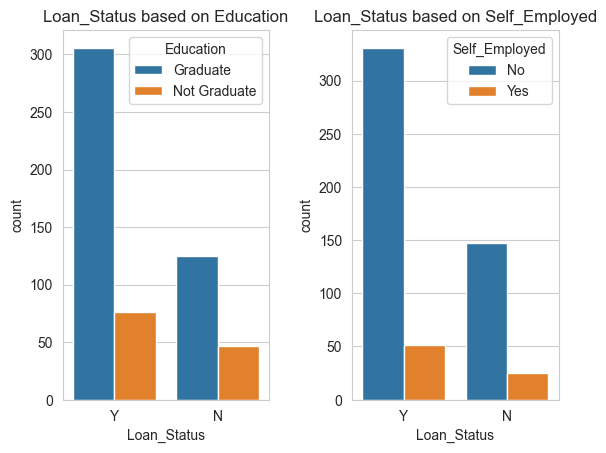

In [197]:
#approval based on Self Employed and Education
plt.figure(figsize=(10,4))

fig,axes = plt.subplots(1, 2, squeeze=False)

sns.countplot(ax=axes[0,0],x='Loan_Status',hue='Education',data=loan).set(title="Loan_Status based on Education")
plt.subplots_adjust(wspace=0.4)
sns.countplot(ax=axes[0,1],x='Loan_Status',hue='Self_Employed',data=loan).set(title="Loan_Status based on Self_Employed")


As per approval status,Graduates and those who are not self-employed dominate the dataset, securing the highest number of loan approvals due to their sheer volume of applications. While Graduate approval counts far exceed those of non-graduates, both groups maintain a similar approval-to-rejection ratio. Similarly, the "Not Self-Employed" category shows a massive lead in approvals, even though self-employed applicants typically request larger average loan amounts. Ultimately, the data indicates that being a Graduate and working for an employer are the strongest predictors for high approval volume.

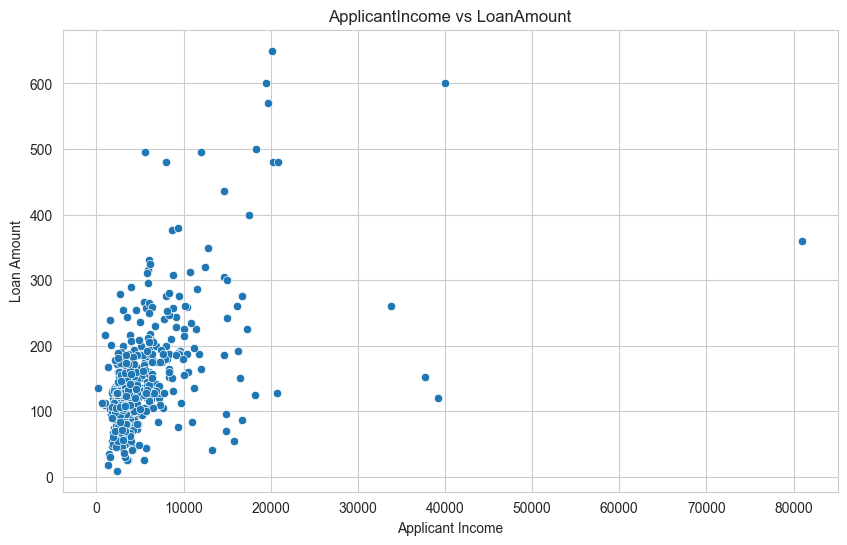

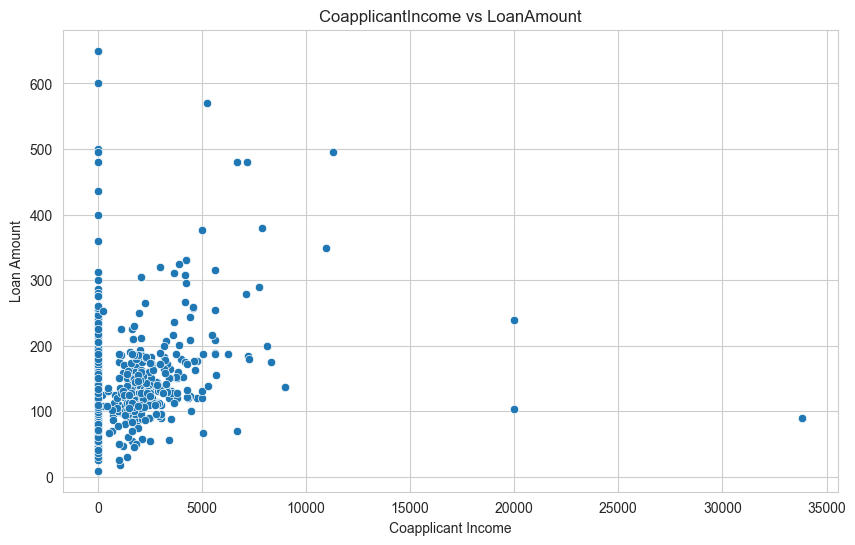

In [198]:
#Task 4. Income Analysis
# Scatter plot for ApplicantIncome vs LoanAmount
plt.figure(figsize=(10,6))
sns.scatterplot(x='ApplicantIncome', y='LoanAmount', data=loan)
plt.title('ApplicantIncome vs LoanAmount')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.show()

# Scatter plot for CoapplicantIncome vs LoanAmount
plt.figure(figsize=(10,6))
sns.scatterplot(x='CoapplicantIncome', y='LoanAmount', data=loan)
plt.title('CoapplicantIncome vs LoanAmount')
plt.xlabel('Coapplicant Income')
plt.ylabel('Loan Amount')
plt.show()

### Scatter Plot Insight
The scatter plots suggest a generally positive relationship between income and loan amount.  
ApplicantIncome shows a clearer upward pattern with wider spread at higher values.  
CoapplicantIncome appears more dispersed, indicating a weaker direct trend.  
A few extreme points are visible, but they likely represent valid high-income loan cases.  
Overall, income contributes to loan size, with applicant income showing stronger visual influence.

In [199]:
# Correlation
income_cols = ['ApplicantIncome', 'CoapplicantIncome']
for col in income_cols:
    corr = loan[col].corr(loan['LoanAmount'])
    print(f"Correlation between {col} and LoanAmount: {corr:.2f}")

Correlation between ApplicantIncome and LoanAmount: 0.51
Correlation between CoapplicantIncome and LoanAmount: 0.19


### Correlation Insight
The correlation results confirm the linear relationship strength numerically.  
ApplicantIncome has the stronger positive correlation with LoanAmount.  
CoapplicantIncome shows a weaker positive association in comparison.  
This matches the scatter plots, where applicant income has a clearer directional pattern.  
Hence, ApplicantIncome is likely the more informative income predictor for loan amount.

In [200]:
approved_loans = loan[loan['Loan_Status']=='Y']  # Assuming 'Y' means approved

# Applicant income thresholds
applicant_threshold = approved_loans['ApplicantIncome'].quantile([0.25, 0.5, 0.75])
coapplicant_threshold = approved_loans['CoapplicantIncome'].quantile([0.25, 0.5, 0.75])

print("ApplicantIncome thresholds:\n", applicant_threshold)
print("\nCoapplicantIncome thresholds:\n", coapplicant_threshold)


ApplicantIncome thresholds:
 0.25    2885.25
0.50    3813.00
0.75    5771.50
Name: ApplicantIncome, dtype: float64

CoapplicantIncome thresholds:
 0.25       0.0
0.50    1244.5
0.75    2281.0
Name: CoapplicantIncome, dtype: float64


### Threshold Insight
From the data, most approved applicants have an ApplicantIncome between 2,885 and 5,772, with the median around 3,813. For coapplicants, 25% of approved loans had no income, while the median coapplicant income is about 1,245, and the top 25% earn more than 2,281. This shows that while a higher applicant income increases the chances of loan approval, having a coapplicant with some income can also help. Many loans are approved even if the coapplicant earns nothing, but combined household income plays a key role in eligibility. In general, a total household income above 5,000 is likely to improve the chances of getting the loan approved.

In [201]:
# Task 5  Loan Term & Interest Rate Analysis
loan[['Loan_Amount_Term', 'Interest_Rate']].describe()


,Loan_Amount_Term,Interest_Rate
count,554.000000,554.000000
mean,342.346570,8.095668
std,64.781026,0.560821
min,12.000000,7.000000
25%,360.000000,8.000000
50%,360.000000,8.000000
75%,360.000000,8.000000
max,480.000000,12.000000


The dataset shows that most loans have a term of 360 months (30 years), with a mean of ~342 months, indicating a few unusually short (12 months) or long (480 months) loans as outliers. The interest rates are tightly clustered around 8%, with a mean of 8.1% and very low variation, though a few loans have higher rates up to 12%. Both features have slight skewness: loan terms are slightly left-skewed due to the short-term outlier, while interest rates are slightly right-skewed because of the high-rate loans. Overall, the majority of borrowers receive standard 30-year loans at typical rates, and the extreme values may warrant further investigation or separate handling in analysis. This indicates a fairly uniform lending pattern with only a few exceptional cases.

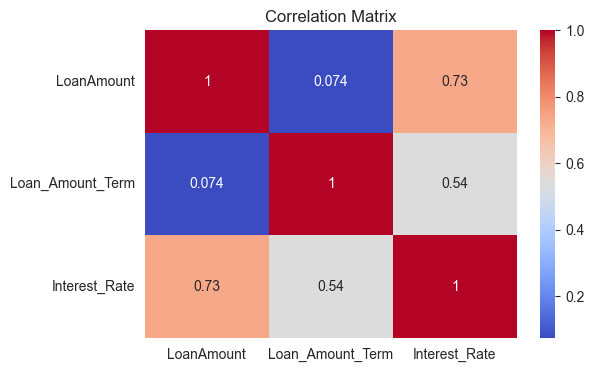

In [202]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(loan[['LoanAmount','Loan_Amount_Term','Interest_Rate']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

The correlation matrix shows that LoanAmount is highly correlated with Interest_Rate rather than Loan_Amount_term.The data reveals that Interest_Rate is primarily driven by LoanAmount ($r = 0.73$) rather than the duration of the loan ($r = 0.54$). While shorter terms (under 120 months) maintain a fixed 7% rate, longer terms like 360 and 480 months show high variance and significant upward outliers reaching 11-12%. Interestingly, the loan amount and the term are nearly independent ($r = 0.074$), suggesting that borrowers' total debt and repayment windows are decided separately.

As from correlation matrix loan amount term and loan amount are nearly independent with r=0.074 so we  don't apply any method to identify optimal loan term ranges for larger loans

In [203]:
#Task 6 Credit History Analysis
credit=loan.groupby("Credit_History")["LoanAmount"].size()
print(credit)

Credit_History
0.0     80
1.0    474
Name: LoanAmount, dtype: int64


There are total of 80 customers with  credit history 0 and 474 with credit history 1 

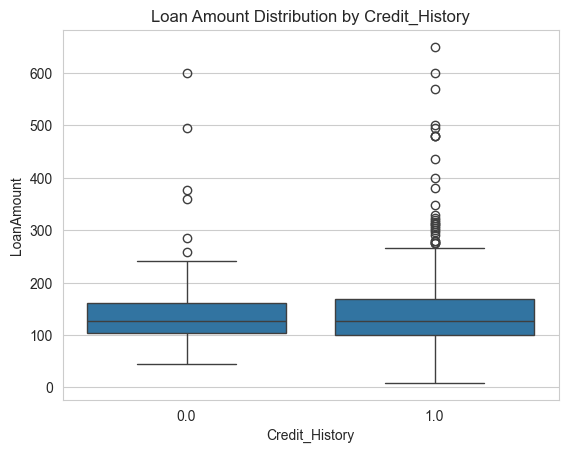

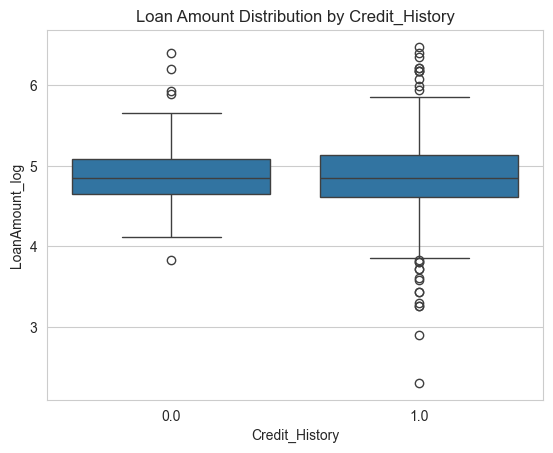

In [204]:
sns.boxplot(x='Credit_History', y='LoanAmount', data=loan)
plt.title("Loan Amount Distribution by Credit_History")
plt.show()

sns.boxplot(x='Credit_History', y='LoanAmount_log', data=loan)
plt.title("Loan Amount Distribution by Credit_History")
plt.show()


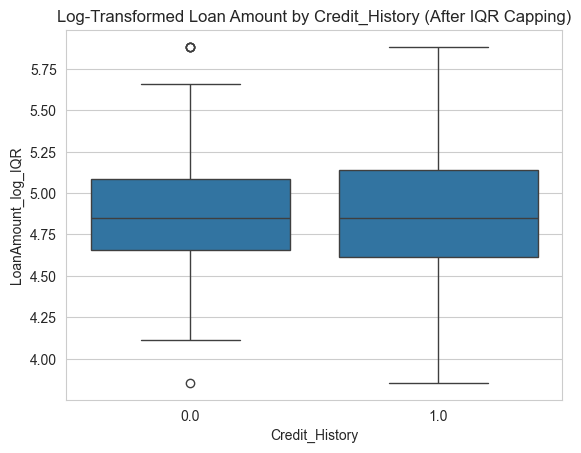

In [205]:
Q1 = loan['LoanAmount_log'].quantile(0.25)
Q3 = loan['LoanAmount_log'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
loan['LoanAmount_log_IQR'] = loan['LoanAmount_log'].clip(lower_bound, upper_bound)


sns.boxplot(x='Credit_History', y='LoanAmount_log_IQR', data=loan)
plt.title("Log-Transformed Loan Amount by Credit_History (After IQR Capping)")
plt.show()

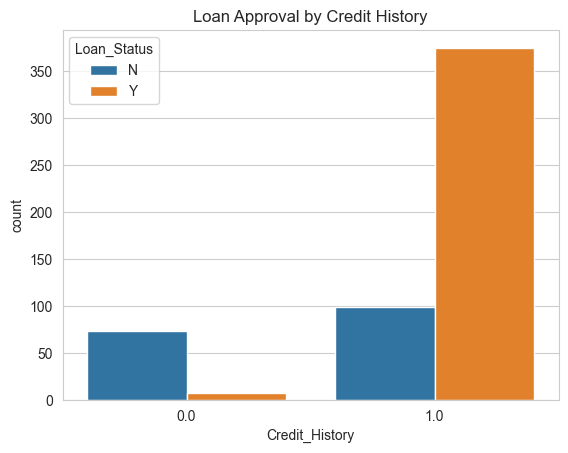

In [206]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=loan)
plt.title("Loan Approval by Credit History")
plt.show()

Credit history does not appear to be a strong predictor of the requested loan amount. People with poor credit (0.0) are applying for similar amounts as those with good credit (1.0).But the number of approved loan for applicant with Credit_History=1 has  greater frequency than with Credit_History=0.0.So, there is high chance of loan being approved for applicant with Credit_History=1.0 .


Property_Area
Rural        163
Semiurban    211
Urban        180
Name: LoanAmount, dtype: int64


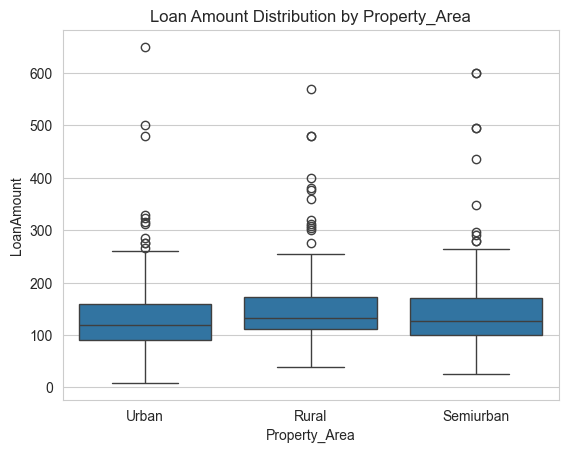

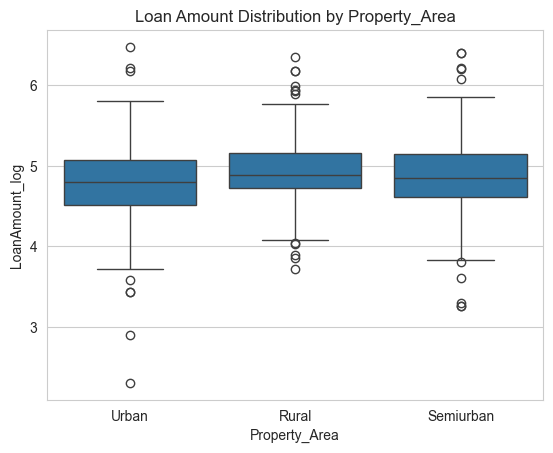

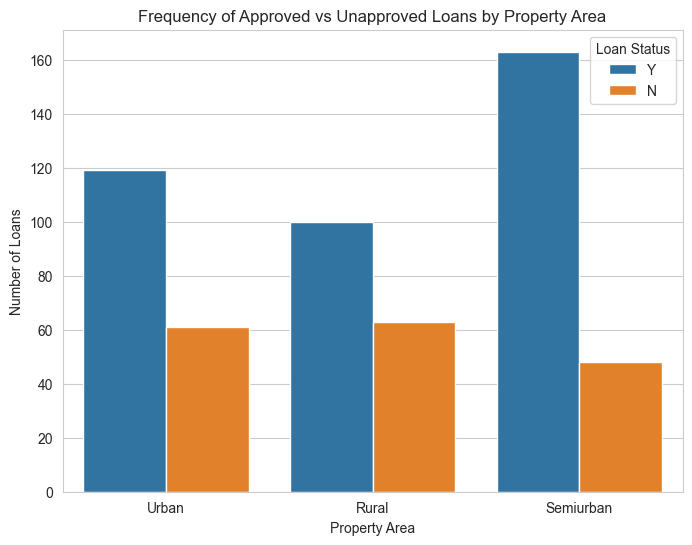

In [207]:
#Task 7


area=loan.groupby('Property_Area')['LoanAmount'].size()
print(area)

sns.boxplot(x='Property_Area', y='LoanAmount', data=loan)
plt.title("Loan Amount Distribution by Property_Area")
plt.show()

sns.boxplot(x='Property_Area', y='LoanAmount_log', data=loan)
plt.title("Loan Amount Distribution by Property_Area")
plt.show()

# Count plot for frequency
plt.figure(figsize=(8,6))
sns.countplot(x="Property_Area", hue="Loan_Status", data=loan)

plt.title("Frequency of Approved vs Unapproved Loans by Property Area")
plt.xlabel("Property Area")
plt.ylabel("Number of Loans")
plt.legend(title="Loan Status")
plt.show()

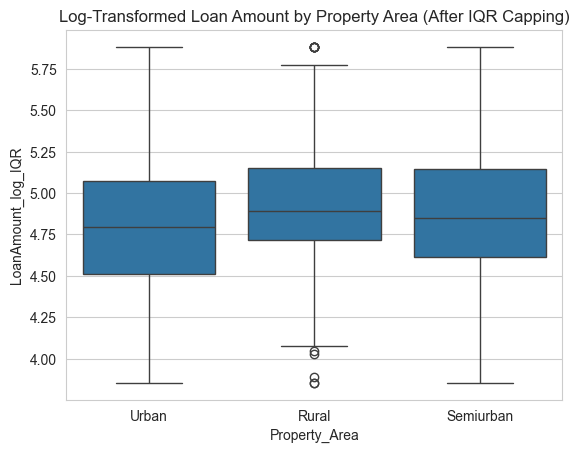

In [208]:
Q1 = loan['LoanAmount_log'].quantile(0.25)
Q3 = loan['LoanAmount_log'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
loan['LoanAmount_log_IQR'] = loan['LoanAmount_log'].clip(lower_bound, upper_bound)


sns.boxplot(x='Property_Area', y='LoanAmount_log_IQR', data=loan)
plt.title("Log-Transformed Loan Amount by Property Area (After IQR Capping)")
plt.show()

The Semiurban region is the clear leader in loan approvals, boasting the highest number of approved loans (over 160) and the lowest number of rejections among all groups. In contrast, Rural areas see the lowest volume of approvals, dipping just below 100. Even though median value is similar for all regions there is high probability of loan being approved for semi-urban and urban region property.

The box plot of original data shows right skewness but log transformed one is seen to be normally distributed as seen through box-plot.

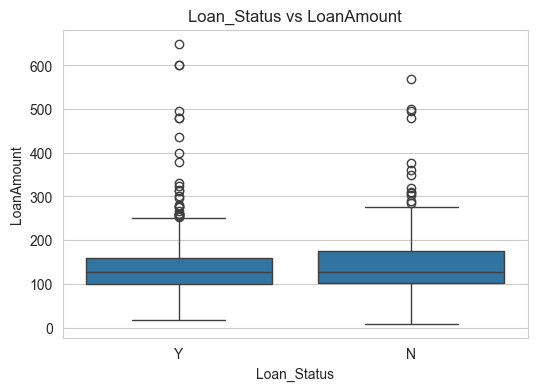

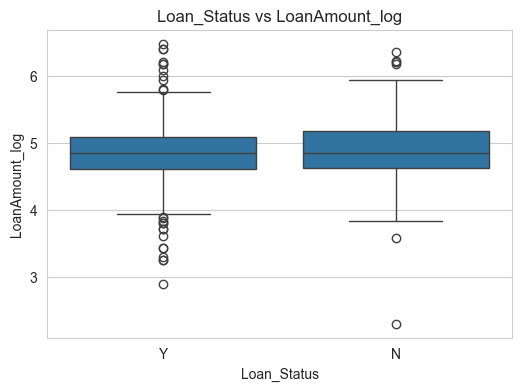

In [209]:
# Task 8 Loan Status Analysis

plt.figure(figsize=(6,4))
sns.boxplot(x='Loan_Status', y='LoanAmount', data=loan)
plt.title("Loan_Status vs LoanAmount")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='Loan_Status', y='LoanAmount_log', data=loan)
plt.title("Loan_Status vs LoanAmount_log")
plt.show()


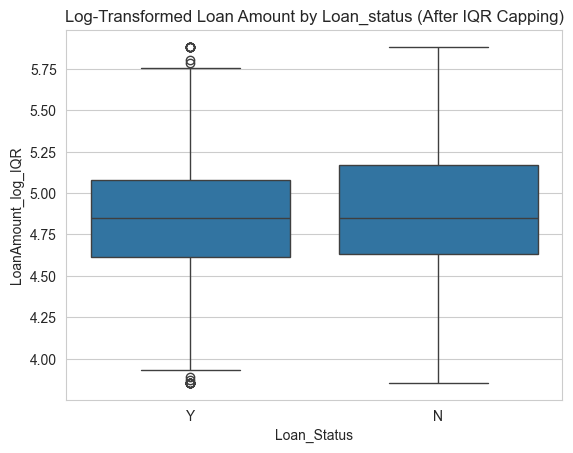

In [210]:
Q1 = loan['LoanAmount_log'].quantile(0.25)
Q3 = loan['LoanAmount_log'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
loan['LoanAmount_log_IQR'] = loan['LoanAmount_log'].clip(lower_bound, upper_bound)


sns.boxplot(x='Loan_Status', y='LoanAmount_log_IQR', data=loan)
plt.title("Log-Transformed Loan Amount by Loan_status (After IQR Capping)")
plt.show()

In [211]:
# Skewness of approved loan amount for original dataset
approved_skew = loan[loan['Loan_Status'] == 'Y']['LoanAmount'].skew()
print("Skewness of Approved Loan Amount:", approved_skew)

# Skewness of approved loan amount for log transformed LoanAmount
approved_skew = loan[loan['Loan_Status'] == 'Y']['LoanAmount_log'].skew()
print("Skewness of Approved Loan Amount:", approved_skew)

Skewness of Approved Loan Amount: 2.826295130555734
Skewness of Approved Loan Amount: -0.20433464919177344


Loan amount distributions for approved and rejected loans show substantial overlap. The median loan amount for rejected loans is slightly higher than approved loans, indicating that higher loan amounts are not more likely to be approved. Both groups exhibit right-skewed distributions with several high-value outliers. This suggests that loan approval depends more on other factors such as income, credit history, and eligibility rather than loan amount alone.

However the log transformed LoanAmount shows less outliers and skewness is also -0.204 which is in suitable range.The value -0.2 is very close to 0, so the distribution is nearly symmetric.

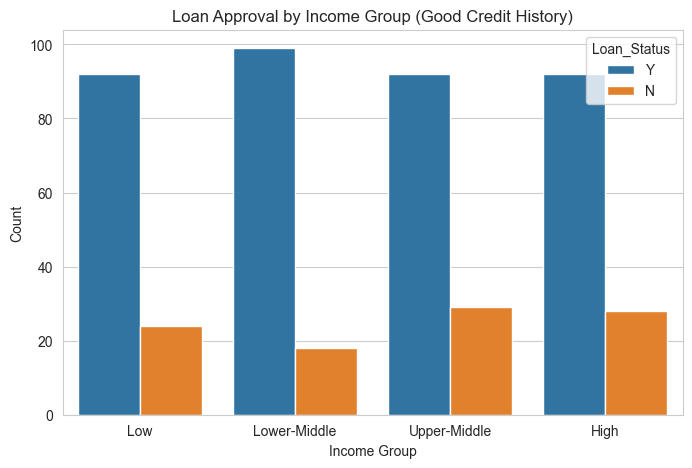

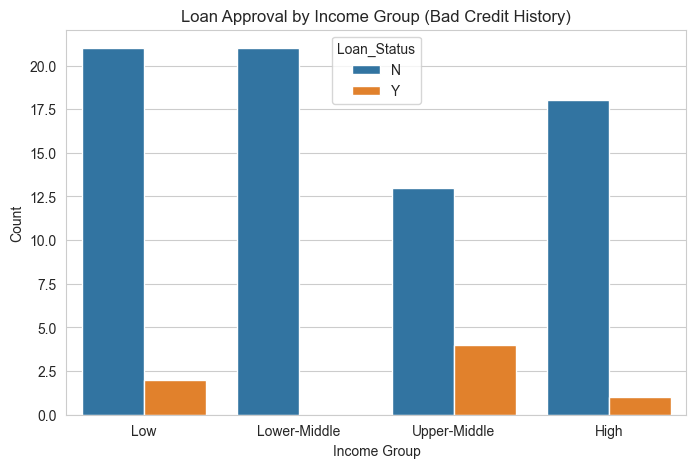

In [212]:
# Task 9
# Create income bins
loan['Income_bin'] = pd.qcut(loan['ApplicantIncome'], 4, labels=[
    'Low', 'Lower-Middle', 'Upper-Middle', 'High'
])
plt.figure(figsize=(8,5))
sns.countplot(x='Income_bin', hue='Loan_Status',
              data=loan[loan['Credit_History']==1])

plt.title("Loan Approval by Income Group (Good Credit History)")
plt.xlabel("Income Group")
plt.ylabel("Count")
plt.show()


plt.figure(figsize=(8,5))
sns.countplot(x='Income_bin', hue='Loan_Status',
              data=loan[loan['Credit_History']==0])

plt.title("Loan Approval by Income Group (Bad Credit History)")
plt.xlabel("Income Group")
plt.ylabel("Count")
plt.show()

The data clearly shows that Credit History is the dominant factor in loan approvals, far outweighing the influence of Income Group. For those with a "Good Credit History," the approval counts (Status: Y) are consistently high across all income levels, reaching their peak in the "Lower-Middle" bracket. Conversely, a "Bad Credit History" serves as a near-universal barrier; even "High" income earners in this category face overwhelming rejections. While higher income does not guarantee a pass for those with poor credit, it is notable that the "Upper-Middle" group saw a marginal, though still negligible, increase in approvals compared to other "Bad Credit" groups. Ultimately, maintaining a solid credit score appears to be the most critical requirement for securing a loan, regardless of whether an applicant falls into a Low or High income group.

As for gender vs loan amount we already visualised in above task 2 which showed Male applicant apply for higher loan amount than female and high approval chance of male compared to female.

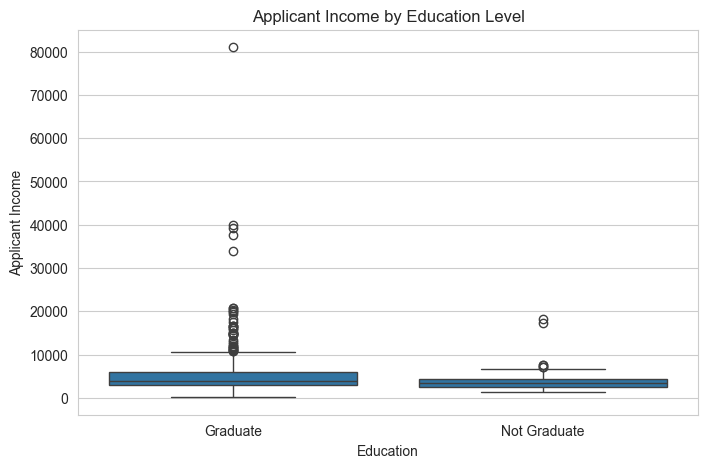

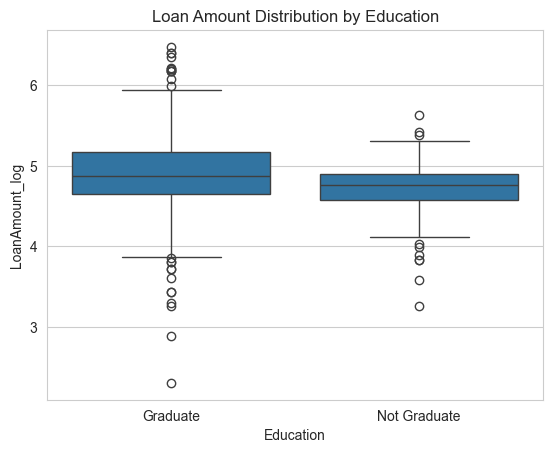


Loan Approval Rate by Education:
Loan_Status          N         Y
Education                       
Graduate      0.290023  0.709977
Not Graduate  0.382114  0.617886


In [213]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Education', y='ApplicantIncome', data=loan)

plt.title("Applicant Income by Education Level")
plt.xlabel("Education")
plt.ylabel("Applicant Income")
plt.show()

sns.boxplot(x='Education', y='LoanAmount_log', data=loan)
plt.title("Loan Amount Distribution by Education")
plt.show()


edu_approval = loan.groupby('Education')['Loan_Status'].value_counts(normalize=True).unstack()
print("\nLoan Approval Rate by Education:")
print(edu_approval)

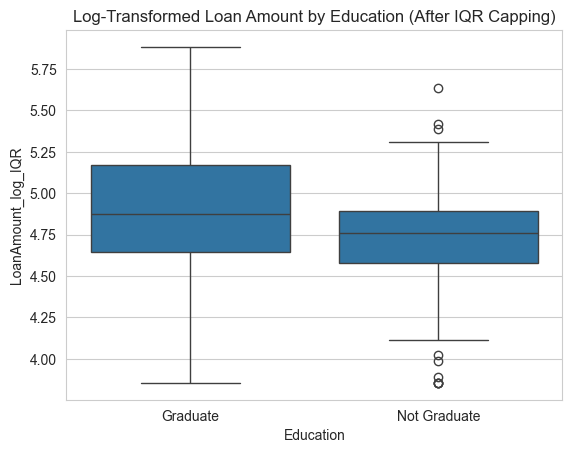

In [214]:
Q1 = loan['LoanAmount_log'].quantile(0.25)
Q3 = loan['LoanAmount_log'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
loan['LoanAmount_log_IQR'] = loan['LoanAmount_log'].clip(lower_bound, upper_bound)


sns.boxplot(x='Education', y='LoanAmount_log_IQR', data=loan)
plt.title("Log-Transformed Loan Amount by Education (After IQR Capping)")
plt.show()

Graduates tend to earn higher and more varied incomes, with several high-earning outliers reaching over 80,000, while the "Not Graduate" group remains much more compressed below 20,000. This financial advantage translates directly into higher loan success rates; approximately 71% of Graduates receive a "Y" (Yes) status for their loans, compared to roughly 61.8% for non-graduates. Conversely, those without a degree face a higher rejection rate of 38.2%, whereas only 29% of graduates are denied.


In [215]:
#Task 10 Feature Engineering Insights

#Total_Income
loan['Total_Income'] = loan['ApplicantIncome'] + loan['CoapplicantIncome']
total_income_skew = loan['Total_Income'].skew()
print("Skewness of Total Income:", total_income_skew)

Total_Income_log=np.log1p(loan['Total_Income'])
print("Skewness of Total Income:", Total_Income_log.skew())


#Debt-to-Income Ratio (DTI)
# Assuming LoanAmount is in thousands; scale accordingly
loan['Debt_to_Income'] = loan['LoanAmount'] / loan['Total_Income']
print(loan[['LoanAmount',  'Total_Income','Debt_to_Income']].head())

print('\n')

#Loan-to-Value Proxy (LTV Proxy)
loan['LTV_Proxy'] = loan['LoanAmount'] / loan['Property_Area'].map({'Urban': 120, 'Semiurban': 100, 'Rural': 80})
print(loan[['LoanAmount', 'LTV_Proxy']].head())
print('\n')

#Income bands or categories
loan['Income_Band'] = pd.cut(
    loan['Total_Income'],
    bins=[0, 5000, 7000, 9000, 1e6],  # Adjust bins as needed
    labels=['Low', 'Medium', 'High', 'Very High']
)
print(loan[['LoanAmount', 'Income_Band']].head())

Skewness of Total Income: 5.8597845180105645
Skewness of Total Income: 0.8956543859227803
   LoanAmount  Total_Income  Debt_to_Income
0       127.0        5849.0        0.021713
1       128.0        6091.0        0.021015
2        66.0        3000.0        0.022000
3       120.0        4941.0        0.024287
4       141.0        6000.0        0.023500


   LoanAmount  LTV_Proxy
0       127.0   1.058333
1       128.0   1.600000
2        66.0   0.550000
3       120.0   1.000000
4       141.0   1.175000


   LoanAmount Income_Band
0       127.0      Medium
1       128.0      Medium
2        66.0         Low
3       120.0         Low
4       141.0      Medium


We engineered new features in the loan dataset to improve predictive insights. First, we calculated Total_Income by summing applicant and coapplicant incomes to capture household repayment capacity. Then, we created the Debt-to-Income ratio as a measure of borrower risk and a Loan-to-Value (LTV) proxy using property area to approximate equity in the property. Finally, we categorized total income into Income Bands (Low, Medium, High, Very High) to capture non-linear effects in modeling. These engineered features provide richer, more interpretable data for analysis and predictive modeling.

In [216]:
loan.to_csv('loan_model.csv')

After new engineered featured we save to loan_encoded.csv for further processing and model training.